Read the data and make visualization

In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")          
    print('GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print('CPU')


GPU: Tesla T4


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import glob
import cv2

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path= glob.glob('/content/drive/MyDrive/B. Disease Grading/*')
path = path[2:]
path

['/content/drive/MyDrive/B. Disease Grading/2. Groundtruths',
 '/content/drive/MyDrive/B. Disease Grading/1. Original Images']

In [6]:
labels_path = glob.glob(path[0]+'/*')
images_path = glob.glob(path[1]+'/*')


In [7]:

images_path[0]

'/content/drive/MyDrive/B. Disease Grading/1. Original Images/b. Testing Set'

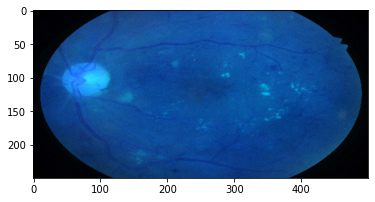

In [20]:
#import train and test images
Train, Test = [],[]

file = glob.glob(images_path[1]+'/*.jpg') # read the training path
for j in file: 
    img = cv2.imread(j)

    crop_top = 0  # row index of the top-left corner of the crop
    crop_left = 200  # column index of the top-left corner of the crop
    crop_bottom = crop_top + 3000  # row index of the bottom-right corner of the crop
    crop_right = crop_left + 3550  # column index of the bottom-right corner of the crop

    cropped_img = img[crop_top:crop_bottom, crop_left:crop_right, :]

    Train.append(cv2.resize(cropped_img,(500,250)))

file = glob.glob(images_path[0]+'/*.jpg') # read the test path
for j in file: 
    img = cv2.imread(j)

    crop_top = 0  # row index of the top-left corner of the crop
    crop_left = 200  # column index of the top-left corner of the crop
    crop_bottom = crop_top + 3000  # row index of the bottom-right corner of the crop
    crop_right = crop_left + 3550  # column index of the bottom-right corner of the crop

    cropped_img = img[crop_top:crop_bottom, crop_left:crop_right, :]

    Test.append(cv2.resize(cropped_img,(500,250)))

plt.imshow(Train[50])

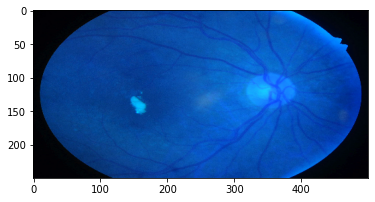

In [9]:
plt.imshow(Test[70])

In [10]:
print("trainingset contains:",len(Train),"and the testset contains ",len(Test))

trainingset contains: 413 and the testset contains  103


In [11]:
#now we are going to upload the labels 
path[0]

'/content/drive/MyDrive/B. Disease Grading/2. Groundtruths'

In [12]:
Label_train = pd.read_csv(path[0]+'/a. IDRiD_Disease Grading_Training Labels.csv')


Label_train = Label_train.iloc[:,[1,2]]
Label_train  

,Retinopathy grade,Risk of macular edema
0,3,2
1,3,2
2,2,2
3,3,2
4,4,0
...,...,...
408,2,1
409,2,0
410,2,0
411,2,0


In [13]:
Label_train.iloc[4,1]

0

In [14]:
Label_train['Risk of macular edema '].value_counts()


2    195
0    177
1     41
Name: Risk of macular edema , dtype: int64

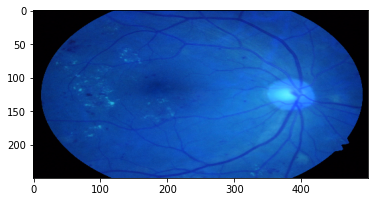

In [15]:
img = Train[0].copy()
h_flipped = cv2.flip(img,0)
plt.imshow(h_flipped)

In [55]:
#in this case our data in unbalanced, so we need to make the data augmentation to make it balanced and increase the data in the same time
number, typ= 0,0
new_Train = Train.copy()
new_Labels = Label_train.copy()
# we first have to add more 18 picture of the classe 0 and add 154 picture for class 1
for i in range(len(Train)):
    if((Label_train.iloc[i,1]) == 0 and number <18):
        number += 1
        img = Train[i].copy()
    
        flipped = cv2.flip(img, typ)
        if (typ ==0):
            typ =1
        else:
            typ=0
    
    new_Train.append(flipped)
    new_Labels.loc[len(new_Labels)] = [(Label_train.iloc[i,0]), (Label_train.iloc[i,1])]
    #new_Labels.append(0)
  
    elif ((Label_train.iloc[i,1]) == 1):
        for i in range (4):
            img = Train[i].copy()
            
            flipped = cv2.flip(img, typ)
            if (typ == 0):
                typ = 1
            else:
                typ = 0
            print(Label_train.iloc[i,1])  
            new_Train.append(flipped)
            new_Labels.loc[len(new_Labels)] = [(Label_train.iloc[i,0]), (Label_train.iloc[i,1])]
      #new_labels.append(1)


#2: we will make a picture by 5: i mean say that every picture will be 5 picture
#new_Labels = np.array(new_labels)

2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2


In [48]:
print(len(new_Labels), len(Label_train))

595 413


In [49]:
new_Labels['Risk of macular edema '].value_counts()

2    359
0    195
1     41
Name: Risk of macular edema , dtype: int64

In [ ]:
Label_test = pd.read_csv(path[0]+'/b. IDRiD_Disease Grading_Testing Labels.csv')

Label_test = Label_test.iloc[:,[1,2]]
Label_test  

,Retinopathy grade,Risk of macular edema
0,4,0
1,4,1
2,4,0
3,4,0
4,4,1
...,...,...
98,0,0
99,2,1
100,1,0
101,2,2


Creat the CNN for classification

In [ ]:
#import libraries
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
